# Image Plagiarism Detection with Equivariant Encoders

The problem is to learn a binary classifier that determines whether two images are related by a plagiarism manipulation (geometric transformation, color distortion, overlay, etc.) or are unrelated.

Image plagiarism detection requires robustness to geometric manipulations: rotations, reflections, shifts. Standard ViT encoders lack invariance and rely on data
augmentation. We propose a Siamese network with equivariant Vision Transformer
encoders guaranteeing invariance by construction. Equivariant encoders eliminate
geometric augmentations during training. We compare four ViT encoders pre-
trained identically via DINOv2 on ImageNet-1K, isolating the architectural effect.

A function $f : X \to Y$ (a whole network or a single layer) is called **group equivariant** with respect to a group $G$ and fixed group representations $\rho_X : G \to GL(X)$, $\rho_Y : G \to GL(Y)$ if:
\begin{equation}
  f(\rho_X(g)(x)) = \rho_Y(g)(f(x)) \quad \text{for all } x \in X \text{ and } g \in G.
\end{equation}
When $\rho_Y$ is the trivial representation ($\rho_Y(g) = \mathrm{id}$ for all $g$), the function is called **group invariant**: $f(\rho_X(g)(x)) = f(x)$.

The structure of a Siamese network:
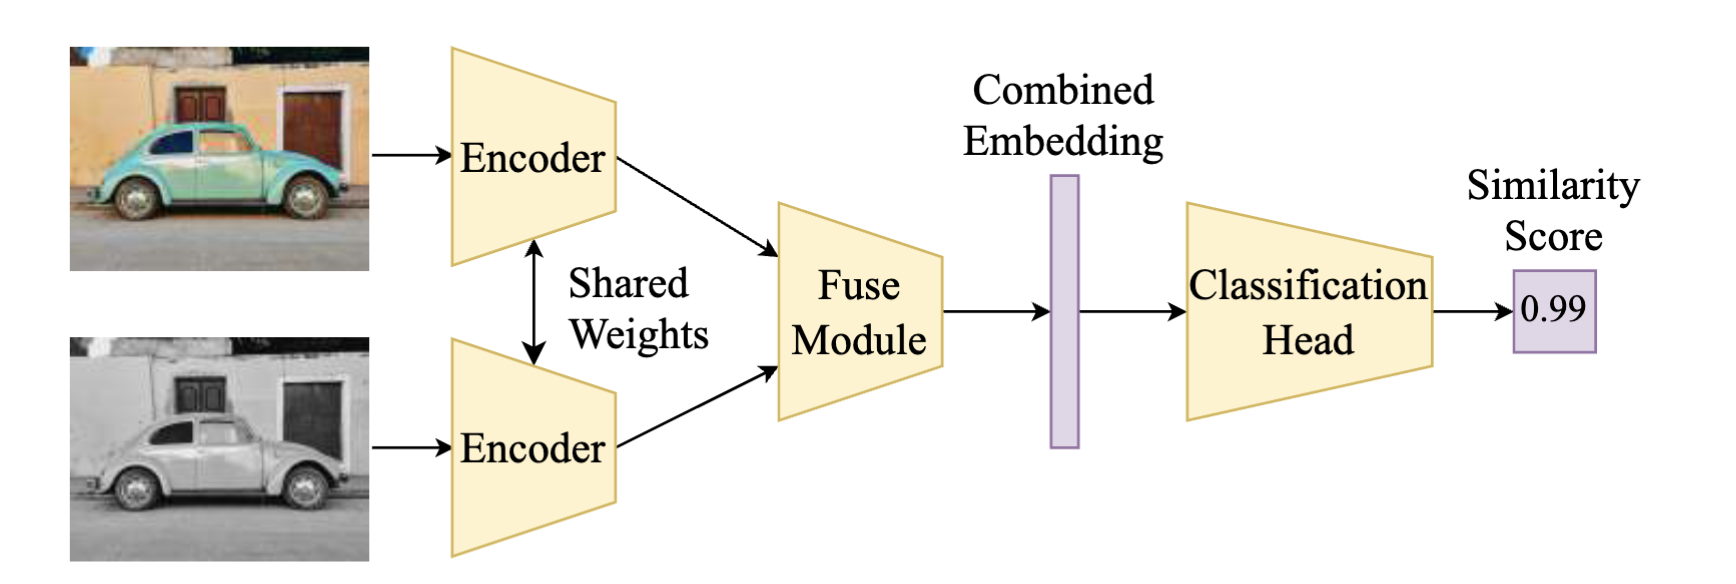

In [1]:
import os
import torch

IS_KAGGLE = os.path.exists("/kaggle")

if IS_KAGGLE:
    BASE_DIR = "/kaggle/working"
else:
    BASE_DIR = "."

COCO_IMAGES = os.path.join(BASE_DIR, "coco_images")
RUNS_DIR    = os.path.join(BASE_DIR, "runs")
os.makedirs(COCO_IMAGES, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Base dir: {BASE_DIR}")


Device: cuda
Base dir: /kaggle/working


## Code for image augmentations

We need these augmentations for training the models

In [2]:
import torchvision.transforms as transforms
import numpy as np
import random
import string
from torchvision.transforms import functional
from PIL import Image, ImageDraw, ImageFont

class RandomCompose(object):
    """
    Composes several augmentations together with a given probability.

    Args:
        transforms (List[Transform]): List of transforms to compose.
        p (float): Probability of applying each transform.

    Example:
        >>> RandomCompose([
        >>>     transforms.CenterCrop(10),
        >>>     transforms.ToTensor(),
        >>> ], p=0.5)
    """
    def __init__(self, transforms, p=0.5):
        self.p = p
        self.transforms = transforms

    def __call__(self, img):
        for t in self.transforms:
            if random.random() < self.p:
                img = t(img)
        return img

class AddTextOverlay(object):
    def __init__(self, 
                 font_size_range=(20, 200), 
                 opacity_range=(0.4, 1.0),
                 text_length_range=(5, 12),
                 special_chars="©®™€$#№@"):
        self.font_size_range = font_size_range
        self.opacity_range = opacity_range
        self.text_length_range = text_length_range
        self.special_chars = special_chars
        self.predefined_texts = ["© 2024", "Sample", "Confidential", "Draft", "TEST", "PRIVATE", "UNCLASSIFIED"]

    def __call__(self, img):
        if img.mode != 'RGBA':
            img = img.convert('RGBA')
        draw = ImageDraw.Draw(img)
        
        if random.random() < 0.5:
            text = random.choice(self.predefined_texts)
        else:
            chars = string.ascii_letters + string.digits + self.special_chars
            text_length = random.randint(*self.text_length_range)
            text = ''.join(random.choices(chars, k=text_length))
        
        color = random.choice([(255, 255, 255, 255), (0, 0, 0, 255)])
        opacity = int(255 * random.uniform(*self.opacity_range))
        fill_color = (color[0], color[1], color[2], opacity)
        
        x = random.randint(10, max(10, img.width - 100))
        y = random.randint(10, max(10, img.height - 50))
        
        draw.text((x, y), text, fill=fill_color)
        return img.convert('RGB')

class AddWatermark(object):
    def __init__(self, opacity_range=(0.3, 0.7), size_ratio_range=(0.05, 0.2)):
        self.opacity_range = opacity_range
        self.size_ratio_range = size_ratio_range

    def __call__(self, img):
        watermark = Image.new("RGBA", (50, 50), (255, 255, 255, 128))
        opacity = random.uniform(*self.opacity_range)
        watermark = watermark.resize((
            int(img.width * random.uniform(*self.size_ratio_range)),
            int(img.height * random.uniform(*self.size_ratio_range))
        ))
        watermark.putalpha(int(255 * opacity))
        
        pos = random.choice([
            (10, 10),
            (img.width - watermark.width - 10, 10),
            (img.width // 2 - watermark.width // 2, img.height // 2 - watermark.height // 2)
        ])
        img = img.convert("RGBA")
        img.paste(watermark, pos, watermark)
        return img.convert("RGB")

class AddColoredSquare(object):
    def __init__(self,
                 size_ratio_range=(0.1, 0.3),
                 opacity_range=(0.7, 1.0)):
        self.size_ratio_range = size_ratio_range
        self.opacity_range = opacity_range

    def __call__(self, img):
        if img.mode != 'RGBA':
            img = img.convert('RGBA')
        draw = ImageDraw.Draw(img)

        size_ratio = random.uniform(*self.size_ratio_range)
        square_size = int(min(img.width, img.height) * size_ratio)

        x = random.randint(0, img.width - square_size)
        y = random.randint(0, img.height - square_size)

        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
        opacity = int(255 * random.uniform(*self.opacity_range))
        fill_color = (color[0], color[1], color[2], opacity)

        draw.rectangle([x, y, x + square_size, y + square_size], fill=fill_color)

        return img.convert('RGB')

class CenterCrop(object):
    """
    Randomly crops the image from the center with a random size.
    """
    def __init__(self):
        pass

    def __call__(self, img):
        crop = random.uniform(1, 5)
        w, h = img.size
        h = int(h * (1 - crop / 100))
        w = int(w * (1 - crop / 100))
        img = functional.center_crop(img, [h, w])
        return img

class Crop(object):
    """
    Randomly crops the image with a random size and position.
    """
    def __init__(self):
        pass

    def __call__(self, img):
        size = random.uniform(1, 10)
        w, h = img.size
        max_left = max(0, int(w * size / 100))
        max_top = max(0, int(h * size / 100))
        left = random.randint(0, max_left)
        top = random.randint(0, max_top)
        min_width = int(w * (1 - size / 100)) - left
        max_width = w - left - 1
        if min_width > max_width:
            min_width = max_width
        width = random.randint(max(1, min_width), max(1, max_width))
        min_height = int(h * (1 - size / 100)) - top
        max_height = h - top - 1
        if min_height > max_height:
            min_height = max_height
        height = random.randint(max(1, min_height), max(1, max_height))
        img = functional.crop(img, top=top, left=left, height=height, width=width)
        return img

class GaussianBlur(object):
    """
    Applies Gaussian blur to the image with a random kernel size.

    Args:
        kernel_sizes (List[int]): List of possible kernel sizes.
    """
    def __init__(self, kernel_sizes=[3, 5]):
        self.kernel_sizes = kernel_sizes

    def __call__(self, img):
        kernel = random.choice(self.kernel_sizes)
        img = functional.gaussian_blur(img, (kernel, kernel))
        return img

class Scale(object):
    """
    Randomly scales the image with a scale factor between 0.3 and 2.
    """
    def __init__(self):
        pass

    def __call__(self, img):
        if random.random() > 0.2:
            scale = random.uniform(0.3, 2)
            w, h = img.size
            h = int(h * scale)
            w = int(w * scale)
            img = functional.resize(img, size=(h, w))
        else:
            scale_h = random.uniform(0.3, 2)
            scale_w = random.uniform(0.3, 2)
            w, h = img.size
            h = int(h * scale_h)
            w = int(w * scale_w)
            img = functional.resize(img, size=(h, w))
        return img

class RandomRotation90(object):
    """
    Randomly rotates the image by 90 degrees.
    """
    def __call__(self, img):
        angle = random.choice([90, 180, 270])
        
        img = functional.rotate(
            img, 
            angle, 
            expand=True)
        return img

class Grayscale(object):
    """
    Converts the image to grayscale (3-channel output to keep pipeline compatible).
    
    Args:
        p (float): Probability of applying grayscale conversion.
    """
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            img = functional.to_grayscale(img, num_output_channels=3)
        return img

class GaussianNoise(object):
    """
    Adds Gaussian noise to the image with a random standard deviation.

    Args:
        mean (float): Mean of the Gaussian noise.
    """
    def __init__(self, mean=0.0):
        self.mean = mean

    def __call__(self, img):
        img_array = np.array(img)
        std = np.random.uniform(0.5, 2.0)
        noise = np.random.normal(self.mean, std, img_array.shape)
        noisy_img_array = img_array + noise
        noisy_img_array = np.clip(noisy_img_array, 0, 255).astype(np.uint8)
        img = Image.fromarray(noisy_img_array)
        return img

class CombinedAugmentation(object):
    """
    Applies a combination of all augmentations with a given probability.
    """
    def __init__(self, p=0.5):
        self.p = p
        self.augmentations = [
            AddWatermark(),
            AddTextOverlay(),
            AddColoredSquare(),
            CenterCrop(),
            Crop(),
            GaussianNoise(),
            transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3)], p=1.0),
            GaussianBlur(kernel_sizes=[3, 5]),
            Scale(),
            RandomRotation90(),
            Grayscale(),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip()
        ]

    def __call__(self, img):
        for aug in self.augmentations:
            if random.random() < self.p:
                img = aug(img)
        return img

def get_augmentations(skip_d4=False):
    simple_transform = RandomCompose([
        AddWatermark(),
        AddTextOverlay(),
        Crop(),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3)], p=0.4),
        Scale(),
    ])

    augs = [
        AddWatermark(),
        AddColoredSquare(),
        AddTextOverlay(),
        CenterCrop(),
        Crop(),
        GaussianNoise(),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3)], p=1.),
        GaussianBlur(kernel_sizes=[3, 5]),
        Scale(),
    ]
    if not skip_d4:
        augs += [RandomRotation90(), Grayscale(), transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip()]
    else:
        augs += [Grayscale()]

    train_transform = RandomCompose(augs)
    return simple_transform, train_transform

def get_validation_augmentations():
    """
    Returns a dictionary of image transformations for validation testing.
    Each transformation is applied with 100% probability (no random skipping).
    """
    augmentations = {
        'no_augmentation': lambda x: x,
        
        'add_text_overlay': AddTextOverlay(),
        'add_watermark': AddWatermark(),
        'add_colored_square': AddColoredSquare(),
        'center_crop': CenterCrop(),
        'random_crop': Crop(),
        'gaussian_blur': GaussianBlur(kernel_sizes=[3, 5]),
        'scale': Scale(),
        'rotate_90': lambda x: functional.rotate(x, 90, expand=True),
        'rotate_180': lambda x: functional.rotate(x, 180, expand=True),
        'rotate_270': lambda x: functional.rotate(x, 270, expand=True),
        'grayscale': Grayscale(p=1.0),
        'horizontal_flip': transforms.RandomHorizontalFlip(p=1.0),
        'vertical_flip': transforms.RandomVerticalFlip(p=1.0),
        'diagonal_flip': transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            lambda x: functional.rotate(x, 90, expand=True)
        ]),
        'anti_diagonal_flip': transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            lambda x: functional.rotate(x, 270, expand=True)
        ]),
        'gaussian_noise': GaussianNoise(),
        'color_jitter': transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3),
        
        'geometric_watermark': transforms.Compose([
            lambda x: functional.rotate(x, 90, expand=True),
            AddWatermark()
        ]),
        
        'text_overlay_watermark': transforms.Compose([
            AddTextOverlay(),
            AddWatermark()
        ]),
        
        'geometric_text_overlay': transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            AddTextOverlay()
        ]),
        
        'color_geometric': transforms.Compose([
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3),
            lambda x: functional.rotate(x, 90, expand=True)
        ]),
        
        'all_overlays': transforms.Compose([
            AddTextOverlay(),
            AddWatermark(),
            AddColoredSquare()
        ]),
        
        'full_augmentation_set1': transforms.Compose([
            lambda x: functional.rotate(x, 90, expand=True),
            AddTextOverlay(),
            GaussianBlur(kernel_sizes=[3, 5])
        ]),
        
        'full_augmentation_set2': transforms.Compose([
            AddWatermark(),
            GaussianNoise(),
            Grayscale(p=1.0)
        ]),

        'combined_augmentation': CombinedAugmentation(p=0.5)
    }
    
    return augmentations


## Dataset

We use COCO val2017 (5000 images, resized to 224 × 224). 10% of the dataset is used for validation

In [3]:
kaggle_coco = "/kaggle/input/coco-2017-dataset/coco2017/val2017"

if os.path.isdir(kaggle_coco):
    COCO_IMAGES = kaggle_coco
    print(f"Using Kaggle COCO dataset: {COCO_IMAGES}")
elif not os.listdir(COCO_IMAGES):
    !wget -q --show-progress http://images.cocodataset.org/zips/val2017.zip -O /tmp/val2017.zip
    !unzip -q /tmp/val2017.zip -d {COCO_IMAGES}
    !rm /tmp/val2017.zip
    print(f"Downloaded COCO to {COCO_IMAGES}")
else:
    print(f"COCO already present at {COCO_IMAGES}")


/tmp/val2017.zip    100%[===================>] 777.80M   105MB/s    in 8.1s    
Downloaded COCO to /kaggle/working/coco_images


In [4]:
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CocoDataset(Dataset):
    def __init__(self, images_dir, preprocessor, split="train", val_size=0.1, random_seed=42, skip_d4=False):
        self.preprocessor = preprocessor
        self.simple_transform, self.train_transform = get_augmentations(skip_d4=skip_d4)

        image_paths = []
        for root, _, files in os.walk(images_dir):
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(root, file))

        random.Random(random_seed).shuffle(image_paths)
        split_idx = int(len(image_paths) * (1 - val_size))

        if split == "train":
            self.image_paths = image_paths[:split_idx]
        elif split in ["val", "test"]:
            self.image_paths = image_paths[split_idx:]
        else:
            raise ValueError("split must be 'train', 'val', or 'test'")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        augmented1 = self.train_transform(image)
        augmented2 = self.simple_transform(image)
        return self.preprocessor(augmented1), self.preprocessor(augmented2)

In [5]:
def get_coco_dataloaders(images_dir, preprocessor, batch_size=32, num_workers=4,
                         val_size=0.1, random_seed=42, skip_d4=False):
    """
    Creates train and test dataloaders for the COCO dataset with unified train/test split.

    Args:
        images_dir (str): Root path to the dataset.
        preprocessor (callable): Image-to-tensor processor (e.g., CLIPProcessor).
        batch_size (int): Batch size for loaders.
        num_workers (int): Number of subprocesses for data loading.
        val_size (float): Fraction of data to use for test set.
        random_seed (int): Seed for reproducible split.

    Returns:
        dict: {'train': train_loader, 'test': test_loader}
    """
    train_dataset = CocoDataset(images_dir=images_dir, preprocessor=preprocessor,
                                split="train", val_size=val_size, random_seed=random_seed, skip_d4=skip_d4)
    test_dataset = CocoDataset(images_dir=images_dir, preprocessor=preprocessor,
                               split="test", val_size=val_size, random_seed=random_seed, skip_d4=skip_d4)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return {
        'train': train_loader,
        'test': test_loader
    }


## Code for training

**Training pipelene:**

 Batch of images $\{\mathbf{I}_i\}_{i=1}^B$ undergoes two distinct sets of transformations, $T_1$ and $T_2$.
  $T_1$ represents a primary set of augmentations designed to simulate significant manual changes, while $T_2$ consists of simple augmentations that minimally alter the images.
  Each image in the batch is transformed by both $T_1$ and $T_2$, resulting in two augmented versions of each image.
  These augmented images are then processed by an encoder $g$ to produce embeddings $\mathbf{z}$.
  The resulting embeddings form a matrix of pairwise comparisons, where the diagonal elements represent positive pairs.
  The function $\mathbf{h}\bigl[\mathbf{q}(\mathbf{z}_B^1, \mathbf{z}_i^2)\bigr]$ evaluates the similarity between the embeddings of the augmented pairs, facilitating self-supervised learning without the need for explicit labeling.
  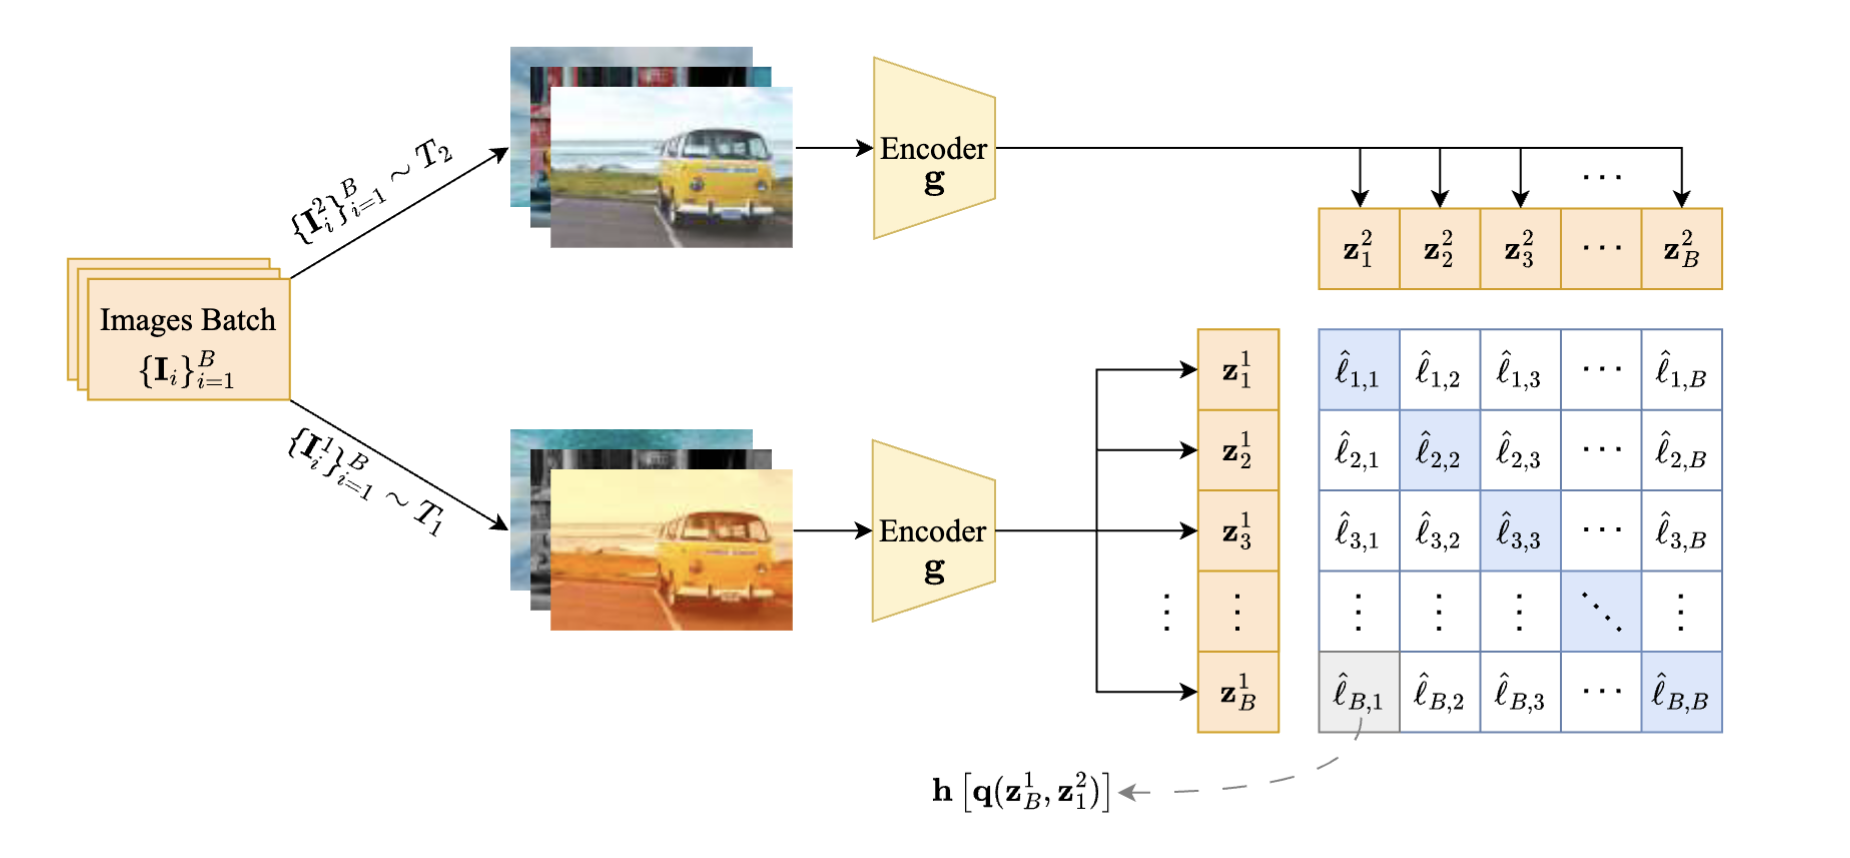

The total loss for the dataset $\mathcal{D}$ is defined as:
\begin{equation}
  \mathcal{L}_{\mathrm{total}}(\mathcal{D}) = \frac{1}{N} \sum_{i=1}^{N} \bigl[ \mathcal{L}_{\mathrm{BCE}}(\mathbf{I}_i^{(1)}, \mathbf{I}_i^{(2)}, \ell_i) + \lambda \cdot \mathcal{L}_{\mathrm{contr}}(\mathbf{I}_i^{(1)}, \mathbf{I}_i^{(2)}, \ell_i) \bigr],
\end{equation}
where $\lambda$ is a regularization parameter. The weighted binary cross-entropy (class reweighting to reduce false positives) is:
\begin{equation}
  \mathcal{L}_{\mathrm{BCE}}(\mathbf{I}_i^{(1)}, \mathbf{I}_i^{(2)}, \ell_i) = -\bigl[ w_{+}\, \ell_i \log(\hat{\ell}_i) + w_{-}\, (1 - \ell_i) \log(1 - \hat{\ell}_i) \bigr], \quad \hat{\ell}_i = f_\theta(\mathbf{I}_i^{(1)}, \mathbf{I}_i^{(2)}),
\end{equation}
with $w_{+} = 0.3$ and $w_{-} = 0.7$.


For the contrastive regularization, the **$L^2$ Euclidean distance** is used to measure pair similarity, following Hadsell, Chopra & LeCun (CVPR 2006):

$$L^2(z_1,z_2,y)=y\|z_1-z_2\|^2+(1-y)\max(0,\,m-\|z_1-z_2\|)^2$$

where $y=1$ for genuine (plagiarism) pairs and $y=0$ for impostor pairs, and $m=1$ is the margin. This directly shapes the Euclidean geometry of the embedding space without relying on cosine normalization.

In [6]:
from torchmetrics import MetricCollection
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score, BinaryRecall, BinaryPrecision
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

def make_metrics(device):
    return MetricCollection({
        'accuracy':  BinaryAccuracy(),
        'f1':        BinaryF1Score(),
        'recall':    BinaryRecall(),
        'precision': BinaryPrecision(),
    }).to(device)


def train_model(model, train_loader, test_loader, optimizer, scheduler,
                num_epochs, device, regularizer=None, lam=0.05, checkpoint_interval=1,
                log_dir='runs'):
    os.makedirs(log_dir, exist_ok=True)
    writer = SummaryWriter(log_dir)
    history = {
            'train_loss': [], 'val_loss': [],
            'train_accuracy': [], 'val_accuracy': [],
            'train_f1': [], 'val_f1': [],
            'train_recall': [], 'val_recall': [],
            'train_precision': [], 'val_precision': [],
            'lr': [],
        }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_total = 0
        train_metrics = make_metrics(device)

        for batch1, batch2 in tqdm(train_loader):
            batch1, batch2 = batch1.to(device), batch2.to(device)
            batch_size = batch1.size(0)
            pairs_batch_size = batch_size ** 2

            optimizer.zero_grad()

            embs1 = model.encoder(batch1)
            embs2 = model.encoder(batch2)

            batch_size1, batch_size2 = embs1.size(0), embs2.size(0)
            embs1_expanded = embs1.unsqueeze(1).expand(-1, batch_size2, -1)
            embs2_expanded = embs2.unsqueeze(0).expand(batch_size1, -1, -1)

            diff_embeddings = torch.abs(embs1_expanded - embs2_expanded).view(-1, model.encoder.feature_dim)
            product_embeddings = (embs1_expanded * embs2_expanded).view(-1, model.encoder.feature_dim)

            if model.use_advanced_head:
                probabilities = model.head(diff_embeddings, product_embeddings).view(-1)
            else:
                probabilities = model.head(diff_embeddings).view(-1)

            labels = torch.eye(batch_size, device=device).view(-1)

            weight = torch.full_like(labels, 0.7)
            weight[labels == 1] = 0.3

            loss = torch.nn.functional.binary_cross_entropy(probabilities, labels, weight=weight)

            if regularizer:
                embs1_all = embs1.unsqueeze(1).expand(batch_size, batch_size, -1).reshape(-1, embs1.size(-1))
                embs2_all = embs2.unsqueeze(0).expand(batch_size, batch_size, -1).reshape(-1, embs2.size(-1))
                contrastive_loss = regularizer(embs1_all, embs2_all, 2 * labels - 1)
                total_loss = loss + lam * contrastive_loss
            else:
                total_loss = loss

            total_loss.backward()
            optimizer.step()

            train_loss += total_loss.item() * pairs_batch_size
            train_total += pairs_batch_size
            train_metrics.update(probabilities.detach(), labels.int())

        scheduler.step()
        tm = train_metrics.compute()
        train_metrics.reset()
        train_loss /= train_total

        model.eval()
        val_loss = 0.0
        val_total = 0
        val_metrics = make_metrics(device)

        with torch.no_grad():
            for batch1, batch2 in tqdm(test_loader):
                batch1, batch2 = batch1.to(device), batch2.to(device)
                batch_size = batch1.size(0)
                pairs_batch_size = batch_size ** 2

                probabilities = model(batch1, batch2).view(-1)
                labels = torch.eye(batch_size, device=device).view(-1)

                weight = torch.full_like(labels, 0.7)
                weight[labels == 1] = 0.3

                loss = torch.nn.functional.binary_cross_entropy(probabilities, labels, weight=weight)

                if regularizer:
                    embs1 = model.encoder(batch1)
                    embs2 = model.encoder(batch2)
                    embs1_all = embs1.unsqueeze(1).expand(batch_size, batch_size, -1).reshape(-1, embs1.size(-1))
                    embs2_all = embs2.unsqueeze(0).expand(batch_size, batch_size, -1).reshape(-1, embs2.size(-1))
                    contrastive_loss = regularizer(embs1_all, embs2_all, 2 * labels - 1)
                    total_loss = loss + lam * contrastive_loss
                else:
                    total_loss = loss

                val_loss += total_loss.item() * pairs_batch_size
                val_total += pairs_batch_size
                val_metrics.update(probabilities, labels.int())

        vm = val_metrics.compute()
        val_metrics.reset()
        val_loss /= val_total

        current_lr = optimizer.param_groups[0]['lr']

        writer.add_scalars('Loss',      {'train': train_loss,    'val': val_loss},        epoch + 1)
        writer.add_scalars('Accuracy',  {'train': tm['accuracy'],'val': vm['accuracy']},  epoch + 1)
        writer.add_scalars('F1',        {'train': tm['f1'],      'val': vm['f1']},        epoch + 1)
        writer.add_scalars('Recall',    {'train': tm['recall'],  'val': vm['recall']},    epoch + 1)
        writer.add_scalars('Precision', {'train': tm['precision'],'val': vm['precision']},epoch + 1)
        writer.add_scalar('LR', current_lr, epoch + 1)

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, '
              f'Train Accuracy: {tm["accuracy"]:.4f}, '
              f'Train F1: {tm["f1"]:.4f}, '
              f'Train Recall: {tm["recall"]:.4f}, '
              f'Train Precision: {tm["precision"]:.4f}, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Accuracy: {vm["accuracy"]:.4f}, '
              f'Val F1: {vm["f1"]:.4f}, '
              f'Val Recall: {vm["recall"]:.4f}, '
              f'Val Precision: {vm["precision"]:.4f}, '
              f'lr: {current_lr}')
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        for m in ('accuracy', 'f1', 'recall', 'precision'):
            history[f'train_{m}'].append(float(tm[m]))
            history[f'val_{m}'].append(float(vm[m]))
        history['lr'].append(current_lr)

    # torch.save({
    #     'epoch': num_epochs,
    #     'model': model.state_dict(),
    #     'optimizer': optimizer.state_dict(),
    #     'scheduler': scheduler.state_dict(),
    # }, f'{log_dir}/epoch_{num_epochs}.pt')

    writer.close()
    return history


2026-04-10 13:17:23.972159: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775827044.173535      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775827044.237402      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775827044.727430      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775827044.727467      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775827044.727470      55 computation_placer.cc:177] computation placer alr

## Encoders

In [7]:
import math

import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vit_l_16, ViT_L_16_Weights


### ViT-L/16

An image $\mathbf{I} \in \mathbb{R}^{224 \times 224 \times 3}$ is split into $14 \times 14 = 196$ non-overlapping patches of size $16 \times 16$, linearly projected to $\mathbb{R}^{1024}$, and processed by 24 transformer blocks. A learnable [CLS]-token is prepended to the patch sequence; after the final layer norm, the [CLS]-token output serves as the image representation $\mathbf{z} \in \mathbb{R}^{1024}$. No equivariance is guaranteed.

In [8]:
class ViTEncoder(nn.Module):
    """
    Pure Vision Transformer encoder using PyTorch's ViT-L/16 model.
    Returns 1024-dimensional features matching ViT-L/16 implementation.
    
    Standard preprocessing is built-in as an attribute:
    encoder.preprocess  # Contains transforms from the loaded weights (resolution may vary)
    
    Example usage:
    # Apply preprocessing to PIL image
    image_tensor = encoder.preprocess(pil_image)
    
    # Get features
    features = encoder(image_tensor.unsqueeze(0))
    
    # Frozen encoder (for feature extraction)
    encoder = ViTEncoder(freeze=True)
    
    # Unfreeze last 3 transformer blocks for fine-tuning
    encoder.unfreeze_last_layers(n_layers=3)
    """
    
    def __init__(self, freeze=True, weights_path=None):
        """
        Args:
            freeze (bool): Freeze backbone weights (True by default)
            weights_path (str, optional): Path to .pth with backbone weights (full SiamNet
                checkpoint with `encoder.backbone.*` keys, or a raw backbone state dict).
                If None, loads torchvision ViT-L/16 ImageNet weights.
        """
        super().__init__()

        weights = ViT_L_16_Weights.DEFAULT
        if weights_path:
            if not os.path.isfile(weights_path):
                raise FileNotFoundError(f"ViT weights not found: {weights_path}")
            self.backbone = vit_l_16(weights=None)
            self.backbone.heads = nn.Identity()
            self._load_backbone_weights(weights_path)
        else:
            self.backbone = vit_l_16(weights=weights)
            self.backbone.heads = nn.Identity()

        self._set_trainable(freeze)
        self.feature_dim = 1024  # ViT-L/16 feature dimension
        self.preprocess = weights.transforms()

    def _load_backbone_weights(self, path):
        raw = torch.load(path, map_location="cpu", weights_only=False)
        if isinstance(raw, dict):
            for key in ("model", "state_dict", "teacher", "model_state_dict"):
                if key in raw:
                    raw = raw[key]
                    break
        if not isinstance(raw, dict):
            raise ValueError(f"Unexpected checkpoint format in {path}")
    
        # Strip common prefixes (DINOv2 teacher/student, DataParallel, etc.)
        cleaned = {}
        for k, v in raw.items():
            nk = k
            for prefix in ("backbone.", "module.", "encoder.", "base_model."):
                if nk.startswith(prefix):
                    nk = nk[len(prefix):]
            cleaned[nk] = v
    
        # DINOv2/DeiT → torchvision ViT key mapping
        mapped = {}
        for k, v in cleaned.items():
            nk = k
            if nk == "cls_token":
                nk = "class_token"
            elif nk == "pos_embed":
                nk = "encoder.pos_embedding"
            elif nk.startswith("patch_embed.proj."):
                nk = nk.replace("patch_embed.proj.", "conv_proj.")
            elif nk.startswith("blocks."):
                nk = nk.replace("blocks.", "encoder.layers.encoder_layer_")
                nk = nk.replace(".attn.qkv.", ".self_attention.in_proj_")
                nk = nk.replace(".attn.proj.", ".self_attention.out_proj.")
                nk = nk.replace(".mlp.fc1.", ".mlp.linear_1.")
                nk = nk.replace(".mlp.fc2.", ".mlp.linear_2.")
                nk = nk.replace(".norm1.", ".ln_1.")
                nk = nk.replace(".norm2.", ".ln_2.")
            elif nk == "norm.weight":
                nk = "encoder.ln.weight"
            elif nk == "norm.bias":
                nk = "encoder.ln.bias"
            mapped[nk] = v
    
        target = self.backbone.state_dict()
        filtered = {
            k: v for k, v in mapped.items()
            if k in target and target[k].shape == v.shape
        }
    
        if not filtered:
            print("Key mapping failed. Checkpoint keys:", list(cleaned.keys())[:10])
            print("Model expects:", list(target.keys())[:10])
        else:
            self.backbone.load_state_dict(filtered, strict=False)
    
        print(f"Loaded {len(filtered)} / {len(target)} params")

    def _set_trainable(self, freeze):
        """Configure layer trainability"""
        for param in self.backbone.parameters():
            param.requires_grad = not freeze

    def unfreeze_last_layers(self, n_layers=3):
        """
        Unfreeze N last layers of the transformer backbone
        
        Args:
            n_layers (int): Number of last transformer blocks to unfreeze
            
        ViT-L/16 structure:
        [conv_proj] -> [class_token, pos_embedding] -> 
        [transformer blocks (24 blocks)] -> [ln] -> [heads]
        """
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        for param in self.backbone.encoder.ln.parameters():
            param.requires_grad = True
        n_layers -= 1
        
        total_blocks = len(self.backbone.encoder.layers)
        assert total_blocks == 24, "ViT-L/16 should have 24 transformer blocks"
        blocks_to_unfreeze = min(n_layers, total_blocks)
        
        for i in range(total_blocks - blocks_to_unfreeze, total_blocks):
            for param in self.backbone.encoder.layers[i].parameters():
                param.requires_grad = True

    def forward(self, x):
        """
        Forward pass through encoder
        
        Args:
            x: Input tensor [batch, 3, H, W] (after standard preprocessing)
            
        Returns:
            torch.Tensor: Feature embeddings [batch, 1024]
        """
        return self.backbone(x)


### Octic ViT ($D_4$-invariant)

The **dihedral group** $D_4 = \{ r, s \mid r^4 = s^2 = e,\; s r s = r^{-1} \}$ of order 8, acting by rotating and reflecting the spatial axes.

The architecture replaces standard layers with $D_4$-equivariant variants. With invariant pooling, the final output is the projection onto the trivial representation, yielding a $D_4$-invariant embedding: $g_\omega(t \cdot \mathbf{I}) = g_\omega(\mathbf{I})$ for all $t \in D_4$.


In [9]:
!git clone -q https://github.com/davnords/octic-vits.git
import sys
sys.path.insert(0, "octic-vits")

In [10]:
from octic_vits import OcticVisionTransformer
import os

class OcticViTEncoder(nn.Module):
    """
    Octic ViT Encoder: D4-equivariant ViT-L/16 (|D4| = 8, the "octic" group).

    Wraps OcticVisionTransformer from https://github.com/davnords/octic-vits

    Reference:
        Nordström, Edstedt, Kahl, Bökman.
        "Octic Vision Transformers: Quicker ViTs Through Equivariance", arXiv:2505.15441, 2025.
    """

    def __init__(self, img_size=224, freeze=True, weights_path=None):
        super().__init__()
        self.feature_dim = 1024

        self.backbone = OcticVisionTransformer(
            img_size=img_size,
            patch_size=16,
            embed_dim=1024,
            depth=24,
            num_heads=16,
            invariant=True,
            num_classes=0,
        )

        if weights_path is not None:
            state = torch.load(weights_path, map_location="cpu", weights_only=False)
            if isinstance(state, dict):
                for key in ("model", "state_dict", "teacher", "model_state_dict"):
                    if key in state:
                        state = state[key]
                        break
        
            # Strip prefixes
            cleaned = {}
            for k, v in state.items():
                nk = k
                for prefix in ("backbone.", "module.", "encoder.", "base_model."):
                    if nk.startswith(prefix):
                        nk = nk[len(prefix):]
                cleaned[nk] = v
        
            # Remove head keys
            cleaned = {k: v for k, v in cleaned.items() if not k.startswith("head.")}
        
            model_state = self.backbone.state_dict()
            filtered = {
                k: v for k, v in cleaned.items()
                if k in model_state and model_state[k].shape == v.shape
            }
        
            if not filtered:
                print("Key mapping failed.")
                print("Checkpoint keys:", list(cleaned.keys())[:10])
                print("Model expects:", list(model_state.keys())[:10])
            else:
                self.backbone.load_state_dict(filtered, strict=False)
        
            print(f"Loaded {len(filtered)} / {len(model_state)} params")

        self._set_trainable(freeze)

        self.preprocess = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def _set_trainable(self, freeze):
        for param in self.backbone.parameters():
            param.requires_grad = not freeze

    def forward(self, x):
        out = self.backbone(x)
        if out.dim() == 3:
            out = out.mean(dim=1)
        return out


### HarmformerEncoder (SE(2)-equivariant)

Implements SE(2)-invariance via **orbit-mean pooling** (Reynolds operator):
for $N$ uniformly spaced rotation angles $\{k\cdot 360°/N\}_{k=0}^{N-1}$ the
embedding is the mean over all rotated copies.

$$\varphi_{SE(2)}(x) = \frac{1}{N}\sum_{k=0}^{N-1}\varphi_{\theta}(R_{k}\,x)$$

For $N = 8$ this gives exact $D_8$-invariance; as $N\to\infty$ it converges
to exact $SO(2)$-invariance. The backbone is the same ViT-L/16 as the
baseline encoder so the comparison is controlled.

Reference: Karella *et al.* "Harmformer: Harmonic Networks Meet Transformers
for Continuous Roto-Translation Equivariance." NeurReps 2024,
arXiv:2411.03794.


In [ ]:
from torchvision.transforms.functional import InterpolationMode
import torchvision.transforms.functional as TF_func


class HarmformerEncoder(nn.Module):
    """
    SE(2)-equivariant encoder inspired by Harmformer (Karella et al., 2024).

    Achieves SO(2)-invariance via orbit-mean pooling (Reynolds operator):
    the embedding is the mean of the backbone outputs over N_rots uniformly
    spaced rotations in [0°, 360°).

    Args:
        N_rots (int): Number of discrete rotations for orbit averaging (default 8).
        freeze (bool): Freeze backbone weights.
        weights_path (str): Optional path to pre-trained ViT-L/16 weights.
    """

    def __init__(self, N_rots: int = 8, freeze: bool = True, weights_path: str = None):
        super().__init__()
        self.feature_dim = 1024
        self.N_rots = N_rots

        weights = ViT_L_16_Weights.DEFAULT
        if weights_path:
            if not os.path.isfile(weights_path):
                raise FileNotFoundError(f"Weights not found: {weights_path}")
            self.backbone = vit_l_16(weights=None)
            self.backbone.heads = nn.Identity()
            self._load_backbone_weights(weights_path)
        else:
            self.backbone = vit_l_16(weights=weights)
            self.backbone.heads = nn.Identity()

        self._set_trainable(freeze)
        self.preprocess = weights.transforms()

    def _load_backbone_weights(self, path: str):
        raw = torch.load(path, map_location="cpu", weights_only=False)
        if isinstance(raw, dict):
            for key in ("model", "state_dict", "teacher", "model_state_dict"):
                if key in raw:
                    raw = raw[key]
                    break
        cleaned = {}
        for k, v in raw.items():
            nk = k
            for prefix in ("backbone.", "module.", "encoder."):
                if nk.startswith(prefix):
                    nk = nk[len(prefix):]
            cleaned[nk] = v
        cleaned = {k: v for k, v in cleaned.items() if not k.startswith("head.")}
        model_state = self.backbone.state_dict()
        filtered = {k: v for k, v in cleaned.items()
                    if k in model_state and model_state[k].shape == v.shape}
        self.backbone.load_state_dict(filtered, strict=False)
        print(f"HarmformerEncoder: loaded {len(filtered)}/{len(model_state)} weight keys")

    def _set_trainable(self, freeze: bool):
        for p in self.parameters():
            p.requires_grad = not freeze

    def unfreeze_last_layers(self, n_layers: int = 3):
        for p in self.parameters():
            p.requires_grad = False
        for p in self.backbone.encoder.layers[-n_layers:].parameters():
            p.requires_grad = True
        for p in self.backbone.ln.parameters():
            p.requires_grad = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Mean-pool ViT-L/16 embeddings over N_rots equidistant rotations.
        Shape: [B, C, H, W] → [B, 1024].
        """
        embs = []
        for k in range(self.N_rots):
            angle = 360.0 * k / self.N_rots
            x_rot = x if angle == 0.0 else TF_func.rotate(
                x, angle, interpolation=InterpolationMode.BILINEAR
            )
            embs.append(self.backbone(x_rot))          # [B, 1024]
        return torch.stack(embs, dim=1).mean(dim=1)    # [B, N_rots, 1024] → [B, 1024]


### ShiftEquivariantEncoder ($\mathbb{Z}^2$-equivariant)

Implements exact $\mathbb{Z}^2$-equivariance via four adaptive modules from Rojas-Gomez et al., CVPR 2024:
- **A-token**: per-sample polyphase offset selection for equivariant patch tokenization
- **A-WSA**: adaptive window self-attention with circular relative positional encoding (A-RPE)
- **A-PMerge**: adaptive patch merging for equivariant spatial downsampling

Base architecture: Swin-T style hierarchical ViT trained from scratch (no DINOv2 init, since DINOv2 ViT-L/16 and Swin-T have incompatible architectures).

In [11]:
class AdaptiveTokenizer(nn.Module):
    """
    A-token from Rojas-Gomez et al., CVPR 2024.
    Selects polyphase offset per sample via energy maximization.
    """
    def __init__(self, patch_size=4, in_channels=3, embed_dim=96):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        P = self.patch_size

        # Compute energy for each polyphase offset per sample: [B, P, P]
        energies = torch.zeros(B, P, P, device=x.device)
        for oh in range(P):
            for ow in range(P):
                poly = x[:, :, oh::P, ow::P]
                energies[:, oh, ow] = poly.pow(2).sum(dim=(1, 2, 3))

        # Per-sample best offset
        flat_idx = energies.view(B, -1).argmax(dim=1)  # [B]
        best_oh = flat_idx // P
        best_ow = flat_idx % P

        # Process each sample with its own offset
        H_trim = (H // P) * P
        W_trim = (W // P) * P
        results = []
        for b in range(B):
            oh, ow = best_oh[b].item(), best_ow[b].item()
            x_shifted = torch.roll(x[b:b+1], shifts=(-oh, -ow), dims=(-2, -1))
            x_trimmed = x_shifted[:, :, :H_trim, :W_trim]
            tokens = self.proj(x_trimmed)
            results.append(tokens)

        tokens = torch.cat(results, dim=0)
        nH, nW = tokens.shape[2], tokens.shape[3]
        tokens = tokens.flatten(2).transpose(1, 2)
        tokens = self.norm(tokens)
        return tokens, (nH, nW)


class CircularRPE(nn.Module):
    """
    A-RPE: Circular relative positional encoding (Rojas-Gomez et al., CVPR 2024).
    Uses modular arithmetic so that relative positions wrap around circularly.
    """
    def __init__(self, window_size, num_heads):
        super().__init__()
        self.window_size = window_size
        self.num_heads = num_heads
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros(window_size * window_size, num_heads)
        )
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)

        coords = torch.arange(window_size)
        grid = torch.stack(torch.meshgrid(coords, coords, indexing='ij'))
        flat = grid.reshape(2, -1)
        rel = flat[:, :, None] - flat[:, None, :]
        rel = rel % window_size
        index = rel[0] * window_size + rel[1]
        self.register_buffer("relative_position_index", index.long())

    def forward(self):
        N = self.window_size * self.window_size
        bias = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(N, N, -1)
        return bias.permute(2, 0, 1).contiguous()


class AdaptiveWindowAttention(nn.Module):
    """
    A-WSA: Adaptive window-based self-attention (Rojas-Gomez et al., CVPR 2024).
    Selects window offset per sample via energy maximization.
    """
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.rpe = CircularRPE(window_size, num_heads)

    def _find_best_offset(self, x_2d):
        """Find best window offset per sample. Returns (best_oh, best_ow) tensors of shape [B]."""
        B, H, W, C = x_2d.shape
        ws = self.window_size

        energies = torch.zeros(B, min(ws, H), min(ws, W), device=x_2d.device)
        for oh in range(min(ws, H)):
            for ow in range(min(ws, W)):
                poly = x_2d[:, oh::ws, ow::ws, :]
                energies[:, oh, ow] = poly.pow(2).sum(dim=(1, 2, 3))

        flat_idx = energies.view(B, -1).argmax(dim=1)
        best_oh = flat_idx // min(ws, W)
        best_ow = flat_idx % min(ws, W)
        return best_oh, best_ow

    def forward(self, x, H, W):
        B, N, C = x.shape
        ws = self.window_size
        x_2d = x.view(B, H, W, C)

        best_oh, best_ow = self._find_best_offset(x_2d)

        nH = H // ws
        nW = W // ws
        rpe_bias = self.rpe().unsqueeze(0)

        all_out = []
        for b in range(B):
            oh, ow = best_oh[b].item(), best_ow[b].item()
            xb = torch.roll(x_2d[b:b+1], shifts=(-oh, -ow), dims=(1, 2))
            xb_win = xb[:, :nH * ws, :nW * ws, :]
            xb_win = xb_win.view(1, nH, ws, nW, ws, C)
            windows = xb_win.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, ws * ws, C)

            qkv = self.qkv(windows).reshape(-1, ws * ws, 3, self.num_heads, self.head_dim)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, v = qkv.unbind(0)

            attn = (q @ k.transpose(-2, -1)) * self.scale
            attn = attn + rpe_bias
            attn = attn.softmax(dim=-1)
            out = (attn @ v).transpose(1, 2).reshape(-1, ws * ws, C)
            out = self.proj(out)

            out = out.view(1, nH, nW, ws, ws, C)
            out = out.permute(0, 1, 3, 2, 4, 5).contiguous().view(1, nH * ws, nW * ws, C)

            result = torch.zeros(1, H, W, C, device=x.device, dtype=x.dtype)
            result[:, :nH * ws, :nW * ws, :] = out
            result = torch.roll(result, shifts=(oh, ow), dims=(1, 2))
            all_out.append(result)

        return torch.cat(all_out, dim=0).view(B, N, C)


class ShiftEqTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = AdaptiveWindowAttention(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Linear(mlp_hidden, dim),
        )

    def forward(self, x, H, W):
        x = x + self.attn(self.norm1(x), H, W)
        x = x + self.mlp(self.norm2(x))
        return x


class AdaptivePatchMerging(nn.Module):
    """
    A-PMerge: Adaptive patch merging (Rojas-Gomez et al., CVPR 2024).
    Per-sample polyphase offset selection for equivariant downsampling.
    """
    def __init__(self, dim):
        super().__init__()
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.view(B, H, W, C)

        # Per-sample best offset
        energies = torch.zeros(B, 2, 2, device=x.device)
        for oh in range(2):
            for ow in range(2):
                poly = x[:, oh::2, ow::2, :]
                energies[:, oh, ow] = poly.pow(2).sum(dim=(1, 2, 3))

        flat_idx = energies.view(B, -1).argmax(dim=1)
        best_oh = flat_idx // 2
        best_ow = flat_idx % 2

        H_even = (H // 2) * 2
        W_even = (W // 2) * 2

        merged_list = []
        for b in range(B):
            oh, ow = best_oh[b].item(), best_ow[b].item()
            xb = torch.roll(x[b:b+1], shifts=(-oh, -ow), dims=(1, 2))
            xb_even = xb[:, :H_even, :W_even, :]
            x0 = xb_even[:, 0::2, 0::2, :]
            x1 = xb_even[:, 1::2, 0::2, :]
            x2 = xb_even[:, 0::2, 1::2, :]
            x3 = xb_even[:, 1::2, 1::2, :]
            merged_list.append(torch.cat([x0, x1, x2, x3], dim=-1))

        merged = torch.cat(merged_list, dim=0)
        new_H, new_W = merged.shape[1], merged.shape[2]
        merged = merged.view(B, -1, 4 * C)
        merged = self.norm(merged)
        merged = self.reduction(merged)
        return merged, new_H, new_W


class ShiftEquivariantEncoder(nn.Module):
    """
    Shift-Equivariant ViT Encoder
    Based on: Rojas-Gomez et al., "Making Vision Transformers Truly Shift-Equivariant", CVPR 2024

    Key modules reimplemented from paper description:
    - A-token: Adaptive tokenization via per-sample polyphase energy maximization
    - A-RPE: Circular-shift-equivariant relative positional encoding
    - A-PMerge: Adaptive patch merging with per-sample equivariant downsampling
    - A-WSA: Adaptive window partitioning for shift-equivariant self-attention

    Base architecture: Swin-T style hierarchical ViT
    """

    def __init__(self, freeze=False):
        super().__init__()

        self.feature_dim = 768
        embed_dim = 96
        depths = [2, 2, 6, 2]
        num_heads = [3, 6, 12, 24]
        window_size = 7

        self.preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

        self.tokenizer = AdaptiveTokenizer(
            patch_size=4, in_channels=3, embed_dim=embed_dim
        )

        self.stages = nn.ModuleList()
        self.merges = nn.ModuleList()
        current_dim = embed_dim

        for i, (depth, heads) in enumerate(zip(depths, num_heads)):
            stage = nn.ModuleList([
                ShiftEqTransformerBlock(current_dim, heads, window_size)
                for _ in range(depth)
            ])
            self.stages.append(stage)

            if i < len(depths) - 1:
                merge = AdaptivePatchMerging(current_dim)
                self.merges.append(merge)
                current_dim *= 2

        self.norm = nn.LayerNorm(current_dim)

        self._set_trainable(freeze)

    def _set_trainable(self, freeze):
        for param in self.parameters():
            param.requires_grad = not freeze

    def unfreeze_last_layers(self, n_layers=3):
        """Unfreeze the last N transformer blocks + final norm."""
        for param in self.parameters():
            param.requires_grad = False

        for param in self.norm.parameters():
            param.requires_grad = True
        n_layers -= 1

        all_blocks = []
        for stage in self.stages:
            for block in stage:
                all_blocks.append(block)

        total_blocks = len(all_blocks)
        blocks_to_unfreeze = min(n_layers, total_blocks)
        for i in range(total_blocks - blocks_to_unfreeze, total_blocks):
            for param in all_blocks[i].parameters():
                param.requires_grad = True

    def forward(self, x):
        B = x.shape[0]
        tokens, (H, W) = self.tokenizer(x)

        for i, stage in enumerate(self.stages):
            for block in stage:
                tokens = block(tokens, H, W)
            if i < len(self.merges):
                tokens, H, W = self.merges[i](tokens, H, W)

        tokens = self.norm(tokens)
        out = tokens.mean(dim=1)
        return out


### Check equivariance

In [12]:
angle_deg, shift_xy = 90.0, (12, 8)

def _pil_roll(pil_img, dx, dy):
    a = np.asarray(pil_img.convert("RGB"))
    return Image.fromarray(np.roll(a, shift=(dy, dx), axis=(0, 1)))

def _cos(z1, z2):
    a, b = F.normalize(z1, dim=-1), F.normalize(z2, dim=-1)
    return float((a * b).sum(dim=-1).mean().item())

rng = np.random.default_rng(0)
_x = np.linspace(0, 255, 224, dtype=np.float32)
_g = (np.outer(_x, np.ones(224)) + np.outer(np.ones(224), _x)) % 256
pil = Image.fromarray(
    np.stack([_g, 255 - _g, (rng.random((224, 224)) * 255)], axis=-1).astype(np.uint8)
)
pil_rot = pil.rotate(angle_deg, resample=Image.BILINEAR, fillcolor=(128, 128, 128))
pil_shift = _pil_roll(pil, *shift_xy)

for name, enc in [
    ("OcticViT", OcticViTEncoder(freeze=True, weights_path="/kaggle/input/datasets/den1shh/d8weightsdinov2/d8_inv_early_dinov2_large_patch16.pth")),
    ("ViT", ViTEncoder(freeze=True, weights_path="/kaggle/input/datasets/den1shh/vitweightsdinov2/dinov2_large_patch16.pth"))
    
]:
    enc.eval().to(device)
    pre = enc.preprocess
    t0, t1, t2 = (pre(p).unsqueeze(0).to(device) for p in (pil, pil_rot, pil_shift))
    with torch.no_grad():
        e0, e1, e2 = enc(t0), enc(t1), enc(t2)
    print(
        f"{name:18}  cos(исходное, поворот)={_cos(e0, e1):.4f}  "
        f"cos(исходное, сдвиг)={_cos(e0, e2):.4f}"
    )


Loaded 717 / 718 params
Loaded 198 / 294 params
OcticViT            cos(исходное, поворот)=1.0000  cos(исходное, сдвиг)=0.8712
ViT                 cos(исходное, поворот)=0.9717  cos(исходное, сдвиг)=0.9902


### Equivariance check (random weights)

Initialise every encoder **from scratch** (random weights, no pretrained checkpoint)
and measure how much the output changes under the group transformation each encoder
claims to be invariant to.

| Metric | Invariant encoder | Non-invariant encoder |
|--------|-------------------|-----------------------|
| `cos_sim` | ≈ 1.000 | < 1 |
| `rel_dist` = ‖z − z′‖ / ‖z‖ | ≈ 0.000 | > 0 |

Because equivariance/invariance is an **architectural** property it must hold
regardless of the weight values — the random-init check is therefore the cleanest
way to verify the structural guarantee.


In [ ]:
import torch.nn.functional as F
from torchvision.transforms import functional as TF_func
from torchvision.transforms.functional import InterpolationMode

# ── Helper: cosine similarity and relative L2 distance ─────────────────────
def _cos_sim(z1, z2):
    return float(F.cosine_similarity(z1, z2, dim=-1).mean().item())

def _rel_dist(z1, z2):
    return float((torch.norm(z1 - z2, p=2, dim=-1) /
                  torch.norm(z1, p=2, dim=-1).clamp(min=1e-8)).mean().item())


def check_invariance(name, encoder, transforms_dict, _device="cpu"):
    """
    Run forward passes under each transformation and report metrics.

    Args:
        transforms_dict: {label: fn(x_NCHW) -> x_NCHW}
    """
    encoder.eval().to(_device)
    torch.manual_seed(0)
    # Synthetic gradient-image so spatial structure is clear
    x = torch.linspace(0, 1, 224).view(1, 224).expand(224, 224)
    y = torch.linspace(0, 1, 224).view(224, 1).expand(224, 224)
    img = torch.stack([x, y, (x + y) / 2], dim=0).unsqueeze(0).to(_device)  # [1,3,224,224]

    with torch.no_grad():
        z0 = encoder(img)

    rows = []
    with torch.no_grad():
        for label, tfm in transforms_dict.items():
            img_t = tfm(img)
            zt    = encoder(img_t)
            rows.append((label, _cos_sim(z0, zt), _rel_dist(z0, zt)))

    print(f"\n{name}")
    print(f"  {'Transform':<22}  {'cos_sim':>8}  {'rel_dist':>9}  {'invariant?':>11}")
    print(f"  {'-'*22}  {'-'*8}  {'-'*9}  {'-'*11}")
    for label, cs, rd in rows:
        ok = "✓  YES" if cs > 0.999 else ("~  APPROX" if cs > 0.98 else "✗  NO")
        print(f"  {label:<22}  {cs:8.4f}  {rd:9.4f}  {ok}")


# ── Reset parameters to random (so no pretrained weights are used) ──────────
def _reset_params(module):
    """Recursively reset all resettable parameters to random values."""
    for m in module.modules():
        if hasattr(m, "reset_parameters"):
            m.reset_parameters()


# ── Common transformations ───────────────────────────────────────────────────
def rot90(x):  return TF_func.rotate(x,  90, interpolation=InterpolationMode.BILINEAR)
def rot180(x): return TF_func.rotate(x, 180, interpolation=InterpolationMode.BILINEAR)
def rot270(x): return TF_func.rotate(x, 270, interpolation=InterpolationMode.BILINEAR)
def hflip(x):  return TF_func.hflip(x)
def vflip(x):  return TF_func.vflip(x)
def shift8(x): return torch.roll(x, shifts=(8, 5), dims=(-2, -1))   # cyclic shift
def rot37(x):  return TF_func.rotate(x,  37, interpolation=InterpolationMode.BILINEAR)
def rot123(x): return TF_func.rotate(x, 123, interpolation=InterpolationMode.BILINEAR)

D4_TRANSFORMS = {
    "Rot 90°":      rot90,
    "Rot 180°":     rot180,
    "Rot 270°":     rot270,
    "H-flip":       hflip,
    "V-flip":       vflip,
}

Z2_TRANSFORMS = {
    "Shift (8,5)px": shift8,
    "Rot 90°":        rot90,   # should NOT be invariant
}

SE2_TRANSFORMS = {
    "Rot 90°":        rot90,
    "Rot 37°":        rot37,
    "Rot 123°":       rot123,
    "Shift (8,5)px":  shift8,
}

# ── 1. ViT-L/16 baseline (no invariance guarantee) ──────────────────────────
from torchvision.models import vit_l_16

class _RandViT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = vit_l_16(weights=None)
        self.backbone.heads = torch.nn.Identity()
        self.feature_dim = 1024
    def forward(self, x): return self.backbone(x)

vit_rand = _RandViT()
check_invariance("ViT-L/16  [no invariance expected]", vit_rand, D4_TRANSFORMS)

# ── 2. Octic ViT (D₄-invariant) ─────────────────────────────────────────────
octic_rand = OcticViTEncoder(freeze=False, weights_path=None)
_reset_params(octic_rand)
check_invariance("Octic ViT  [D₄-invariant expected]", octic_rand, D4_TRANSFORMS)

# ── 3. Shift-Equivariant ViT (ℤ²-invariant) ─────────────────────────────────
shift_rand = ShiftEquivariantEncoder(freeze=False)
# Already random (no pretrained init in ShiftEquivariantEncoder)
check_invariance("Shift-Eq ViT  [ℤ²-inv cyclic shift only]", shift_rand, Z2_TRANSFORMS)

# ── 4. HarmformerEncoder (SE(2)-invariant) ───────────────────────────────────
harm_rand = HarmformerEncoder(N_rots=8, freeze=False)
_reset_params(harm_rand)
check_invariance("Harmformer  [SO(2)-inv via group avg]", harm_rand, SE2_TRANSFORMS)

del vit_rand, octic_rand, shift_rand, harm_rand
torch.cuda.empty_cache()


In [19]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import tensorflow_datasets as tfds

# domains = ['real', 'painting', 'clipart', 'quickdraw', 'infograph', 'sketch']
domains = ['real', 'painting']
counts = {d: 100 for d in domains}
default_count = 20
images, labels = [], []

for domain in domains:
    count = counts.get(domain, default_count)
    ds = tfds.load(f'domainnet/{domain}', split='train', shuffle_files=True)
    ds = ds.shuffle(buffer_size=10000).take(count)
    for example in tfds.as_numpy(ds):
        images.append(Image.fromarray(example['image']).convert('RGB'))
        labels.append(domain)

print(f"Loaded {len(images)} images: { {d: labels.count(d) for d in domains} }")

# 2. Получаем эмбеддинги
encoder = OcticViTEncoder(freeze=True, weights_path="/kaggle/input/datasets/den1shh/d8weightsdinov2/d8_inv_early_dinov2_large_patch16.pth")
encoder.eval().to(device)
preprocess = encoder.preprocess

embeddings = []
with torch.no_grad():
    for img in images:
        t = preprocess(img).unsqueeze(0).to(device)
        emb = encoder(t).cpu().numpy().flatten()
        embeddings.append(emb)

embeddings = np.stack(embeddings)
print(f"Embeddings shape: {embeddings.shape}")

# 3. t-SNE + визуализация


Loaded 200 images: {'real': 100, 'painting': 100}
Loaded 717 / 718 params
Embeddings shape: (200, 1024)


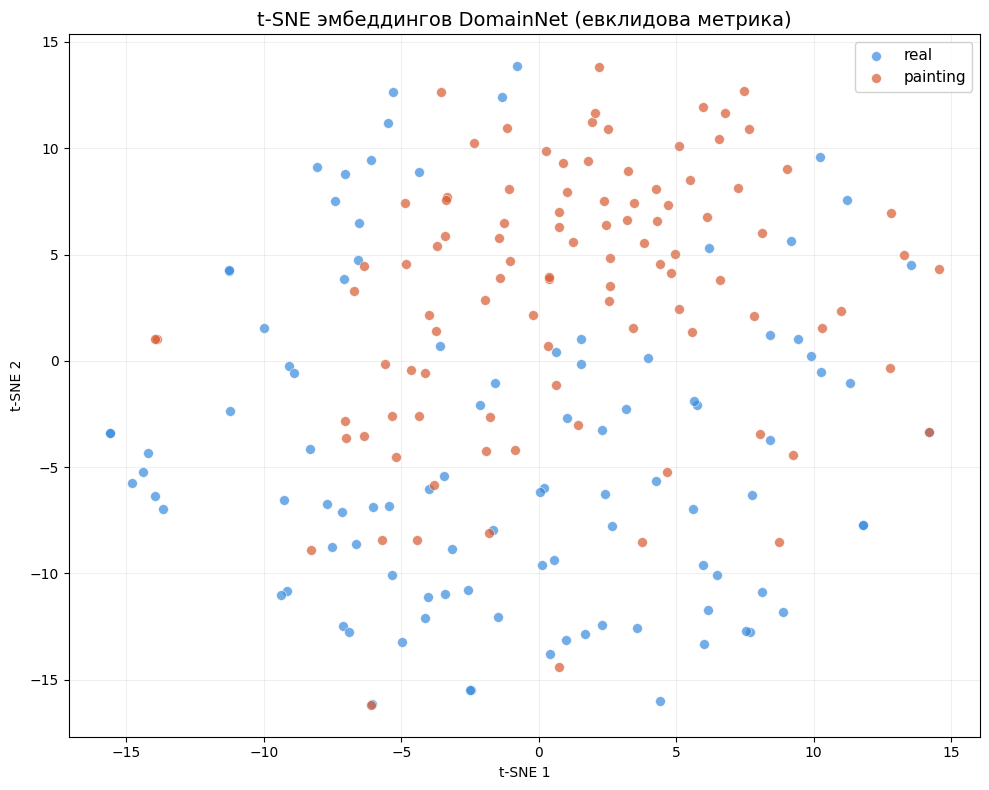

In [20]:
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', random_state=42)
coords = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
colors = {'real': '#378ADD', 'painting': '#D85A30', 'clipart': '#1D9E75',
          'quickdraw': '#D4537E', 'infograph': '#BA7517', 'sketch': '#888780'}

for domain in domains:
    mask = np.array(labels) == domain
    plt.scatter(coords[mask, 0], coords[mask, 1],
                c=colors[domain], label=domain, s=50, alpha=0.7, edgecolors='white', linewidths=0.5)

plt.legend(fontsize=11, framealpha=0.9)
plt.title('t-SNE эмбеддингов DomainNet (евклидова метрика)', fontsize=14)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('tsne_domainnet.png', dpi=150, bbox_inches='tight')
plt.show()

## Siamese network

In [ ]:
class HeadModel(nn.Module):
    """Head for image similarity prediction that accepts pre-computed difference embeddings.
    
    This architecture is designed to work with pre-computed difference vectors between embeddings.
    The input should already be in the format [|emb1 - emb2|] for all pairs.
    """
    
    def __init__(self, feature_dim, dropout_rate=0.1):
        """
        Args:
            feature_dim (int): Dimension of input feature vector (|emb1 - emb2|)
            dropout_rate (float): Dropout probability for regularization. Defaults to 0.1.
        """
        super().__init__()
        
        self.predictor = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(feature_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, diff_embeddings):
        """
        Forward pass for similarity prediction.
        
        Args:
            diff_embeddings: Tensor of shape [batch_size, feature_dim]
                representing pre-computed |embedding1 - embedding2|
        
        Returns:
            Tensor of shape [batch_size, 1] with similarity probabilities (after sigmoid)
        """
        return self.predictor(diff_embeddings)

class AdvancedHeadModel(nn.Module):
    """Advanced head that accepts pre-computed difference AND product embeddings.
    
    This architecture is designed to work with pre-computed difference vectors AND element-wise products.
    The inputs should already be in the format:
    - diff_embeddings: [|emb1 - emb2|] for all pairs
    - product_embeddings: [emb1 * emb2] for all pairs
    """
    
    def __init__(self, feature_dim, dropout_rate=0.1):
        """
        Args:
            feature_dim (int): Dimension of input feature vectors
            dropout_rate (float): Dropout probability. Defaults to 0.1.
        """
        super().__init__()
        
        self.diff_pathway = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.product_pathway = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)
        )
        
        self.fusion = nn.Sequential(
            nn.Linear(2 * feature_dim, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(feature_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, diff_embeddings, product_embeddings):
        """
        Forward pass with pre-computed difference and product features.
        
        Args:
            diff_embeddings: Tensor of shape [batch_size, feature_dim] 
                representing pre-computed |embedding1 - embedding2|
            product_embeddings: Tensor of shape [batch_size, feature_dim]
                representing pre-computed element-wise product of embeddings
                
        Returns:
            Tensor of shape [batch_size, 1] with similarity probabilities (after sigmoid)
        """
        diff_features = self.diff_pathway(diff_embeddings)
        product_features = self.product_pathway(product_embeddings)
        
        combined = torch.cat([diff_features, product_features], dim=1)
        return self.fusion(combined)


In [ ]:
class SiamNet(nn.Module):
    """
    Siamese network with configurable encoder backbone.
    
    Args:
        model_name (str): Type of encoder to use ('efficientnet', 'vit', 'barlowtwins' or 'clip')
        freeze_encoder (bool): Whether to freeze encoder weights during training
        use_advanced_head (bool): Whether to use the advanced head with product features
        unfreeze_n_layers (int): Number of last layers to unfreeze
    """
    def __init__(self, encoder, freeze_encoder=True, use_advanced_head=True, unfreeze_n_layers=None):
        super(SiamNet, self).__init__()
        self.encoder = encoder

        if not freeze_encoder and unfreeze_n_layers is not None:
            self.encoder.unfreeze_last_layers(unfreeze_n_layers)

        self.use_advanced_head = use_advanced_head
        if use_advanced_head:
            self.head = AdvancedHeadModel(self.encoder.feature_dim)
        else:
            self.head = HeadModel(self.encoder.feature_dim)

    def forward(self, batch1: torch.Tensor, batch2: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the siamese network.

        Args:
            batch1: First batch of images [batch_size, channels, height, width]
            batch2: Second batch of images [batch_size, channels, height, width]

        Returns:
            torch.Tensor: Similarity matrix [batch_size1, batch_size2]
        """
        emb1 = self.encoder(batch1)
        emb2 = self.encoder(batch2)

        batch_size1, batch_size2 = emb1.size(0), emb2.size(0)
        emb1_expanded = emb1.unsqueeze(1).expand(-1, batch_size2, -1)
        emb2_expanded = emb2.unsqueeze(0).expand(batch_size1, -1, -1)

        # Pre-compute the difference and product vectors
        diff_embeddings = torch.abs(emb1_expanded - emb2_expanded)
        product_embeddings = emb1_expanded * emb2_expanded
        
        # Reshape for head model
        diff_embeddings = diff_embeddings.view(-1, self.encoder.feature_dim)
        product_embeddings = product_embeddings.view(-1, self.encoder.feature_dim)

        # Pass pre-computed features to the head
        if self.use_advanced_head:
            logits = self.head(diff_embeddings, product_embeddings)
        else:
            logits = self.head(diff_embeddings)
            
        logits = logits.view(batch_size1, batch_size2)
        return logits

    def predict_from_diff_and_product(self, diff_embeddings, product_embeddings):
        """
        Directly predict similarity from pre-computed difference and product vectors.
        
        Args:
            diff_embeddings: Tensor of shape [N, feature_dim] containing pre-computed |emb1 - emb2|
            product_embeddings: Tensor of shape [N, feature_dim] containing pre-computed emb1 * emb2
            
        Returns:
            torch.Tensor: Similarity scores [N, 1]
        """
        if not self.use_advanced_head:
            raise ValueError("This model was initialized with a simple head that doesn't use product embeddings")
        return self.head(diff_embeddings, product_embeddings)
    
    def predict_from_diff(self, diff_embeddings):
        """
        Directly predict similarity from pre-computed difference vectors.
        
        Args:
            diff_embeddings: Tensor of shape [N, feature_dim] containing pre-computed |emb1 - emb2|
            
        Returns:
            torch.Tensor: Similarity scores [N, 1]
        """
        if self.use_advanced_head:
            raise ValueError("This model was initialized with an advanced head that requires product embeddings")
        return self.head(diff_embeddings)

    def predict_similarity(self, batch1: torch.Tensor, batch2: torch.Tensor) -> torch.Tensor:
        """
        Predict similarity between two batches of images.

        Args:
            batch1: First batch of images [batch_size, channels, height, width]
            batch2: Second batch of images [batch_size, channels, height, width]

        Returns:
            torch.Tensor: Similarity vector [batch_size, 1]
        """
        emb1 = self.encoder(batch1)
        emb2 = self.encoder(batch2)

        # Pre-compute the difference and product vectors
        diff_embeddings = torch.abs(emb1 - emb2)
        product_embeddings = emb1 * emb2

        # Pass pre-computed features to the head
        if self.use_advanced_head:
            logits = self.head(diff_embeddings, product_embeddings)
        else:
            logits = self.head(diff_embeddings)

        return logits.view(-1)
    
    def get_preprocessing(self):
        """Returns the preprocessing pipeline for the encoder"""
        return self.encoder.preprocess

## Training

In [ ]:
class L2ContrastiveLoss(torch.nn.Module):
    """
    Hadsell–Chopra–LeCun L² contrastive loss.

        L(z₁, z₂, y) = y·‖z₁−z₂‖² + (1−y)·max(0, m−‖z₁−z₂‖)²

    y = 1 for genuine (plagiarism) pairs, y = 0 for impostor pairs.
    The caller may pass y ∈ {−1, +1} (CosineLoss convention); both are accepted.

    Reference: Hadsell, Chopra, LeCun. "Dimensionality Reduction by Learning
    an Invariant Mapping." CVPR 2006, pp. 1735–1742.
    """

    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, z1: torch.Tensor, z2: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        # Accept both {-1,+1} and {0,1} label conventions
        y_pos = ((y + 1) / 2).clamp(0.0, 1.0)           # genuine=1, impostor=0
        dist = torch.norm(z1 - z2, p=2, dim=-1)
        pos_loss = y_pos * dist.pow(2)
        neg_loss = (1.0 - y_pos) * torch.clamp(self.margin - dist, min=0.0).pow(2)
        return (pos_loss + neg_loss).mean()


regularizer = L2ContrastiveLoss(margin=1.0)


In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
OCTIC_WEIGHTS = "/kaggle/input/datasets/den1shh/d8weightsdinov2/d8_inv_early_dinov2_large_patch16.pth"
NUM_EPOCHS    = 15

# ── 10 experimental configurations: 5 encoders × {no_reg, reg} ─────────────
# skip_d4=True  → Block-P augmentations only (photometric)
# skip_d4=False → Block-P + Block-G augmentations (geometric + photometric)
RUN_CONFIGS = [
    # run_name                   encoder_factory                                              skip_d4  use_reg
    ("vit_baseline_no_reg",  lambda: ViTEncoder(freeze=True),                                True,    False),
    ("vit_baseline_reg",     lambda: ViTEncoder(freeze=True),                                True,    True ),
    ("vit_aug_no_reg",       lambda: ViTEncoder(freeze=True),                                False,   False),
    ("vit_aug_reg",          lambda: ViTEncoder(freeze=True),                                False,   True ),
    ("octic_vit_no_reg",     lambda: OcticViTEncoder(freeze=True, weights_path=OCTIC_WEIGHTS), True,  False),
    ("octic_vit_reg",        lambda: OcticViTEncoder(freeze=True, weights_path=OCTIC_WEIGHTS), True,  True ),
    ("shift_eq_vit_no_reg",  lambda: ShiftEquivariantEncoder(freeze=False),                  True,    False),
    ("shift_eq_vit_reg",     lambda: ShiftEquivariantEncoder(freeze=False),                  True,    True ),
    ("harmformer_no_reg",    lambda: HarmformerEncoder(N_rots=8, freeze=True),               True,    False),
    ("harmformer_reg",       lambda: HarmformerEncoder(N_rots=8, freeze=True),               True,    True ),
]

# ── Training loop ────────────────────────────────────────────────────────────
all_histories = {}

for run_name, make_encoder, skip_d4, use_reg in RUN_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Run: {run_name}  |  skip_d4={skip_d4}  |  L2_reg={use_reg}")
    print(f"{'='*60}")

    encoder = make_encoder()
    preprocessor = encoder.preprocess          # capture before wrapping

    model = SiamNet(encoder, use_advanced_head=True)
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[5, 10], gamma=0.5
    )

    dataloaders = get_coco_dataloaders(
        COCO_IMAGES, preprocessor,
        batch_size=32, num_workers=2, val_size=0.1,
        random_seed=42, skip_d4=skip_d4,
    )

    run_log_dir = os.path.join(RUNS_DIR, run_name)
    history = train_model(
        model, dataloaders["train"], dataloaders["test"],
        optimizer, scheduler,
        num_epochs=NUM_EPOCHS,
        device=device,
        regularizer=regularizer if use_reg else None,
        lam=0.1,
        log_dir=run_log_dir,
    )
    all_histories[run_name] = history

    # Save checkpoint for later evaluation
    ckpt_path = os.path.join(RUNS_DIR, f"{run_name}.pt")
    torch.save(model.state_dict(), ckpt_path)
    print(f"  Checkpoint saved → {ckpt_path}")

    del model, encoder
    torch.cuda.empty_cache()

print(f"\n✓ All 10 runs complete. Checkpoints in: {RUNS_DIR}")


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    ('recall', 'Recall'),
    ('precision', 'Precision'),
    ('f1', 'F1 Score'),
    ('loss', 'Loss'),
]

colors = plt.cm.tab10.colors

for ax, (key, title) in zip(axes.flat, metrics):
    for i, (label, h) in enumerate(all_histories.items()):
        epochs = range(1, len(h[f'train_{key}']) + 1)
        ax.plot(epochs, h[f'train_{key}'], color=colors[i], linestyle='--', alpha=0.5)
        ax.plot(epochs, h[f'val_{key}'], color=colors[i], linestyle='-', label=label)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Training Results', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(RUNS_DIR, 'metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

## Validation on DomainNet

In [ ]:
from sklearn.manifold import TSNE
import tensorflow_datasets as tfds

domains = ['real', 'painting', 'clipart', 'quickdraw', 'infograph', 'sketch']
counts = {d: 40 for d in domains}
default_count = 20
images, labels = [], []

for domain in domains:
    count = counts.get(domain, default_count)
    ds = tfds.load(f'domainnet/{domain}', split='train', shuffle_files=True)
    ds = ds.shuffle(buffer_size=10000).take(count)
    for example in tfds.as_numpy(ds):
        images.append(Image.fromarray(example['image']).convert('RGB'))
        labels.append(domain)

print(f"Loaded {len(images)} images: { {d: labels.count(d) for d in domains} }")

# 2. Получаем эмбеддинги
encoder = OcticViTEncoder(freeze=True, weights_path="/kaggle/input/datasets/den1shh/d8weightsdinov2/d8_inv_early_dinov2_large_patch16.pth")
encoder.eval().to(device)
preprocess = encoder.preprocess

embeddings = []
with torch.no_grad():
    for img in images:
        t = preprocess(img).unsqueeze(0).to(device)
        emb = encoder(t).cpu().numpy().flatten()
        embeddings.append(emb)

embeddings = np.stack(embeddings)
print(f"Embeddings shape: {embeddings.shape}")

# 3. t-SNE + визуализация
tsne = TSNE(n_components=2, perplexity=30, metric='euclidean', random_state=42)
coords = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
colors = {'real': '#378ADD', 'painting': '#D85A30', 'clipart': '#1D9E75',
          'quickdraw': '#D4537E', 'infograph': '#BA7517', 'sketch': '#888780'}

for domain in domains:
    mask = np.array(labels) == domain
    plt.scatter(coords[mask, 0], coords[mask, 1],
                c=colors[domain], label=domain, s=50, alpha=0.7, edgecolors='white', linewidths=0.5)

plt.legend(fontsize=11, framealpha=0.9)
plt.title('t-SNE эмбеддингов DomainNet (евклидова метрика)', fontsize=14)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('tsne_domainnet.png', dpi=150, bbox_inches='tight')
plt.show()

## DomainNet Evaluation: FPR + Recall Protocol

For each of the 6 DomainNet domains (real, painting, clipart, quickdraw, infograph, sketch)
we build a **balanced test set**:
- **100 positive pairs** per transform type: same image + plagiarism transformation
- **100 negative pairs**: images from different classes

Transform types (matching the paper protocol):
`CJ` (ColorJitter), `GN` (Gaussian noise), `GS` (Gaussian blur),
`R90`, `R180`, `R270` (rotations), `WM` (watermark), `COMBO` (combined).

Primary metrics: **FPR** (false positive rate) and **Recall**, stratified by transform.


In [ ]:
import random as _rnd
from torchvision.transforms import functional as TF_func
from torchvision.transforms.functional import InterpolationMode
import torchvision.transforms as T


# ── Plagiarism transformations ────────────────────────────────────────────────
def _apply_transform(img_tensor: torch.Tensor, name: str) -> torch.Tensor:
    """Apply a named plagiarism transformation to a CHW float tensor in [0,1]."""
    if name == "CJ":
        pil = T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)(
            T.ToPILImage()(img_tensor)
        )
        return T.ToTensor()(pil)
    elif name == "GN":
        return (img_tensor + 0.05 * torch.randn_like(img_tensor)).clamp(0, 1)
    elif name == "GS":
        return T.GaussianBlur(kernel_size=5)(img_tensor)
    elif name == "R90":
        return TF_func.rotate(img_tensor, 90, interpolation=InterpolationMode.BILINEAR)
    elif name == "R180":
        return TF_func.rotate(img_tensor, 180, interpolation=InterpolationMode.BILINEAR)
    elif name == "R270":
        return TF_func.rotate(img_tensor, 270, interpolation=InterpolationMode.BILINEAR)
    elif name == "WM":
        from PIL import ImageDraw
        pil = T.ToPILImage()(img_tensor)
        draw = ImageDraw.Draw(pil)
        w, h = pil.size
        draw.text((w // 10, h // 10), "© COPY", fill=(255, 255, 255, 180))
        return T.ToTensor()(pil)
    elif name == "COMBO":
        t = _apply_transform(img_tensor, "CJ")
        t = _apply_transform(t, "R90")
        t = _apply_transform(t, "WM")
        return t
    else:
        raise ValueError(f"Unknown transform: {name}")


TRANSFORM_NAMES = ["CJ", "GN", "GS", "R90", "R180", "R270", "WM", "COMBO"]
DOMAINS         = ["real", "painting", "clipart", "quickdraw", "infograph", "sketch"]


def build_domainnet_pairs(domain: str, preprocess, n_pos: int = 100, n_neg: int = 100,
                          seed: int = 42):
    """
    Load DomainNet images and build positive/negative pairs.

    Returns:
        pos_pairs: List[(t1_tensor, t2_tensor, transform_name)]
        neg_pairs: List[(t1_tensor, t2_tensor)]
    """
    import tensorflow_datasets as tfds

    _rnd.seed(seed)
    torch.manual_seed(seed)

    n_load = n_pos + n_neg * 2 + 200
    ds = tfds.load(f"domainnet/{domain}", split="train", shuffle_files=True)
    ds = ds.shuffle(buffer_size=10000, seed=seed).take(n_load)

    raw = []
    for ex in tfds.as_numpy(ds):
        pil = Image.fromarray(ex["image"]).convert("RGB")
        raw.append(T.ToTensor()(T.Resize((224, 224))(pil)))
    _rnd.shuffle(raw)

    # Positive pairs: reuse each image for all transforms
    n_base = min(n_pos, len(raw) // 3)
    pos_pairs = []
    for t_name in TRANSFORM_NAMES:
        for img in raw[:n_base]:
            t_img = _apply_transform(img, t_name).clamp(0, 1)
            pos_pairs.append((
                preprocess(T.ToPILImage()(img)),
                preprocess(T.ToPILImage()(t_img)),
                t_name,
            ))

    # Negative pairs: disjoint images
    neg_pool_a = raw[n_base : n_base + n_neg]
    neg_pool_b = raw[n_base + n_neg : n_base + 2 * n_neg]
    neg_pairs = [
        (preprocess(T.ToPILImage()(a)), preprocess(T.ToPILImage()(b)))
        for a, b in zip(neg_pool_a, neg_pool_b)
    ]

    return pos_pairs, neg_pairs


@torch.no_grad()
def evaluate_run(model, pos_pairs, neg_pairs, device, threshold: float = 0.5):
    """
    Compute FPR, Recall, F1 for one model on prebuilt pairs.
    Returns dict keyed by transform name + 'ALL'.
    """
    model.eval()
    counts = {t: {"tp": 0, "fp": 0, "tn": 0, "fn": 0}
              for t in TRANSFORM_NAMES + ["ALL"]}

    # Score and cache negative pairs once
    neg_preds = []
    for (img_a, img_b) in neg_pairs:
        p = model(img_a.unsqueeze(0).to(device),
                  img_b.unsqueeze(0).to(device)).item()
        neg_preds.append(int(p >= threshold))

    # Distribute negatives: ALL + round-robin across transforms
    n_tr = len(TRANSFORM_NAMES)
    for i, pred in enumerate(neg_preds):
        t_name = TRANSFORM_NAMES[i % n_tr]
        counts["ALL"][  "fp" if pred else "tn"] += 1
        counts[t_name]["fp" if pred else "tn"] += 1

    # Score positive pairs
    for (img, t_img, t_name) in pos_pairs:
        p = model(img.unsqueeze(0).to(device),
                  t_img.unsqueeze(0).to(device)).item()
        pred = int(p >= threshold)
        counts["ALL"][  "tp" if pred else "fn"] += 1
        counts[t_name]["tp" if pred else "fn"] += 1

    metrics = {}
    for key, c in counts.items():
        tp, fp, tn, fn = c["tp"], c["fp"], c["tn"], c["fn"]
        recall = tp / max(tp + fn, 1)
        fpr    = fp / max(fp + tn, 1)
        prec   = tp / max(tp + fp, 1)
        f1     = 2 * prec * recall / max(prec + recall, 1e-9)
        metrics[key] = {"recall": recall, "fpr": fpr, "f1": f1,
                        "tp": tp, "fp": fp, "tn": tn, "fn": fn}
    return metrics


# ── Main evaluation loop ─────────────────────────────────────────────────────
import pandas as pd

all_eval_results = {}

for run_name, make_encoder, skip_d4, use_reg in RUN_CONFIGS:
    ckpt_path = os.path.join(RUNS_DIR, f"{run_name}.pt")
    if not os.path.exists(ckpt_path):
        print(f"[SKIP] {run_name}: checkpoint not found")
        continue

    print(f"\nEvaluating: {run_name}")
    encoder = make_encoder()
    model = SiamNet(encoder, use_advanced_head=True)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device).eval()
    preprocess = encoder.preprocess

    run_results = {}
    for domain in DOMAINS:
        print(f"  {domain} ...", end=" ", flush=True)
        try:
            pos_pairs, neg_pairs = build_domainnet_pairs(
                domain, preprocess, n_pos=100, n_neg=100
            )
            run_results[domain] = evaluate_run(model, pos_pairs, neg_pairs, device)
            print("done")
        except Exception as e:
            print(f"ERROR: {e}")
            run_results[domain] = {}

    all_eval_results[run_name] = run_results
    del model, encoder
    torch.cuda.empty_cache()

print("\n✓ Evaluation complete.")


In [ ]:
# ── Results: FPR + Recall summary table ──────────────────────────────────────
rows = []
for run_name, domain_results in all_eval_results.items():
    for domain, transform_results in domain_results.items():
        if "ALL" not in transform_results:
            continue
        m = transform_results["ALL"]
        rows.append({
            "run": run_name, "domain": domain,
            "recall": round(m["recall"], 4),
            "fpr":    round(m["fpr"],    4),
            "f1":     round(m["f1"],     4),
        })

df = pd.DataFrame(rows)
if not df.empty:
    pivot_recall = df.pivot_table(
        index="run", columns="domain", values="recall", aggfunc="mean"
    ).round(3)
    pivot_fpr = df.pivot_table(
        index="run", columns="domain", values="fpr", aggfunc="mean"
    ).round(3)

    print("\n=== Recall (↑) by encoder × domain ===")
    print(pivot_recall.to_string())
    print("\n=== FPR (↓) by encoder × domain ===")
    print(pivot_fpr.to_string())

    df.to_csv(os.path.join(RUNS_DIR, "domainnet_results.csv"), index=False)
    print(f"\nSaved to {os.path.join(RUNS_DIR, 'domainnet_results.csv')}")
else:
    print("No results to display.")


In [ ]:
# ── Results: FPR + Recall stratified by transform type ───────────────────────
rows_tr = []
for run_name, domain_results in all_eval_results.items():
    for domain, transform_results in domain_results.items():
        for t_name, m in transform_results.items():
            if t_name == "ALL":
                continue
            rows_tr.append({
                "run": run_name, "domain": domain, "transform": t_name,
                "recall": round(m["recall"], 4),
                "fpr":    round(m["fpr"],    4),
            })

df_tr = pd.DataFrame(rows_tr)
if not df_tr.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    pivot_rec_tr = df_tr.groupby(["run", "transform"])["recall"].mean().unstack("transform")
    pivot_fpr_tr = df_tr.groupby(["run", "transform"])["fpr"].mean().unstack("transform")

    pivot_rec_tr.plot(kind="bar", ax=axes[0], colormap="tab10", width=0.8)
    axes[0].set_title("Recall by encoder × transform type", fontsize=13)
    axes[0].set_ylabel("Recall (↑)")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
    axes[0].legend(title="Transform", fontsize=8, loc="lower right")
    axes[0].grid(axis="y", alpha=0.3)

    pivot_fpr_tr.plot(kind="bar", ax=axes[1], colormap="tab10", width=0.8)
    axes[1].set_title("FPR by encoder × transform type", fontsize=13)
    axes[1].set_ylabel("FPR (↓)")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
    axes[1].legend(title="Transform", fontsize=8, loc="upper right")
    axes[1].grid(axis="y", alpha=0.3)

    fig.suptitle("DomainNet Evaluation: FPR + Recall by Transform", fontsize=15, fontweight="bold")
    fig.tight_layout()

    out_path = os.path.join(RUNS_DIR, "domainnet_fpr_recall_by_transform.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")
else:
    print("No per-transform results to plot.")
